In [11]:
import torch
import torch.nn as nn
import torch.utils
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [13]:
class FF(nn.Module):
    def __init__(self, dim1, dim2, dim3):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(in_features=dim1, out_features=dim2),
            nn.ReLU(),
            nn.Linear(in_features=dim2, out_features=dim3)
        )

    def forward(self, input):
        return self.main(input)

In [ ]:
class VAE(nn.Module):
    def __init__(self, dim1, dim2, dim3):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(dim1, dim2)
        self.fc21 = nn.Linear(dim2, dim3)  # Mean
        self.fc22 = nn.Linear(dim2, dim3)  # Variance
        self.fc3 = nn.Linear(dim3, dim2)
        self.fc4 = nn.Linear(dim2, dim1)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

tmp = VAE(28*28,512,2)
print(tmp)
print(tmp(torch.rand(10,1,28*28))[0].shape)
print(tmp(torch.rand(10,1,28*28))[1].shape)
print(tmp(torch.rand(10,1,28*28))[2].shape)

VAE(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc21): Linear(in_features=512, out_features=2, bias=True)
  (fc22): Linear(in_features=512, out_features=2, bias=True)
  (fc3): Linear(in_features=2, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=784, bias=True)
)
torch.Size([10, 784])
torch.Size([10, 2])
torch.Size([10, 2])


In [15]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 28*28), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [16]:
def train(data_loader, model, optimizer, epochs=20):
    model.to(device)  # GPU
    model.train()
    losses = []
    for epoch in range(epochs):
        for i, (x, _) in enumerate(data_loader):
            x = x.to(device)  # GPU
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(x)
            loss = loss_function(recon_batch, x, mu, logvar)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            if i % 100 == 0:
                print(f"{epoch}/{i}: {loss.item()}")
    return model, losses

In [17]:
def plot_latent(data_loader, model, num_batches=100):
    model.eval()
    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            x = x.to(device)
            mu, logvar = model.encode(x.view(-1, 28*28))
            z = model.reparameterize(mu, logvar)
            z = z.to('cpu').detach().numpy()
            plt.scatter(z[:, 0], z[:, 1], c=y, alpha=0.5)
            if i > num_batches:
                plt.colorbar()
                break

In [18]:
# Load MNIST dataset
transform_vae = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x, start_dim=-2))
])

data_vae = datasets.MNIST('./data', transform=transform_vae, download=True)

data_loader_vae = torch.utils.data.DataLoader(data_vae, batch_size=128, shuffle=True)

# Initialize VAE model
vae_model = VAE(dim1=28*28, dim2=512, dim3=2)

# Initialize optimizer
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

# Train VAE model
trained_model, losses = train(data_loader_vae, vae_model, optimizer)

0/0: 70557.3984375
0/100: 24883.212890625
0/200: 23523.873046875
0/300: 22220.1015625
0/400: 22594.9921875
1/0: 22494.544921875
1/100: 21820.9453125
1/200: 20937.87109375
1/300: 22272.556640625
1/400: 20857.66015625
2/0: 21104.478515625
2/100: 20422.15234375
2/200: 21294.689453125
2/300: 21154.041015625
2/400: 20141.82421875
3/0: 20491.37890625
3/100: 21097.080078125
3/200: 20782.478515625
3/300: 20193.7421875
3/400: 20728.62109375
4/0: 21179.353515625
4/100: 20629.578125
4/200: 19997.859375
4/300: 20517.623046875
4/400: 19422.08984375
5/0: 19617.22265625
5/100: 19400.474609375
5/200: 19573.9765625
5/300: 20031.224609375
5/400: 20545.169921875
6/0: 20486.8515625
6/100: 19706.1640625
6/200: 19751.29296875
6/300: 20736.72265625
6/400: 21292.34765625
7/0: 20173.96484375
7/100: 20065.5859375
7/200: 20453.876953125
7/300: 20356.43359375
7/400: 19576.330078125
8/0: 20099.19921875
8/100: 19560.90234375
8/200: 20577.65234375
8/300: 19842.861328125
8/400: 19036.548828125
9/0: 19844.349609375
9/

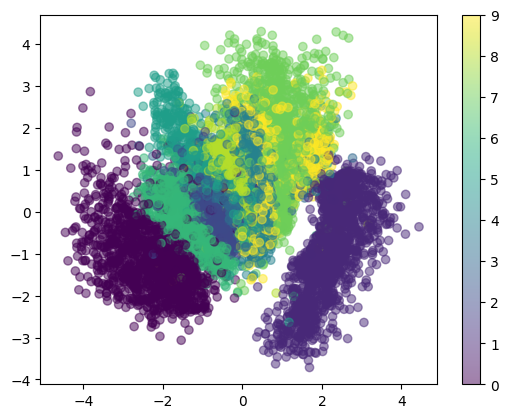

In [19]:
# Plot latent space
plot_latent(data_loader_vae, trained_model)
plt.show()

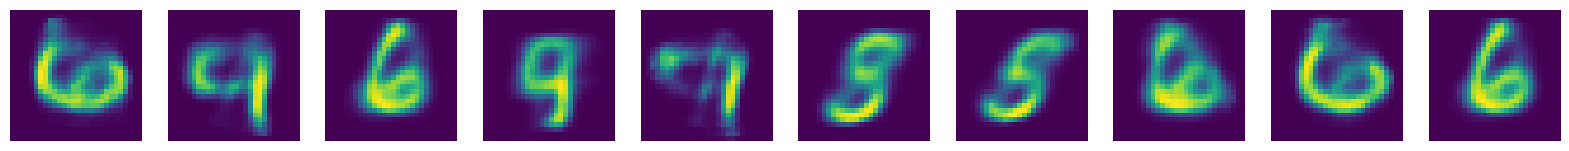

<Figure size 640x480 with 0 Axes>

In [73]:
def plot_generated_samples(model, num_samples=10):
    with torch.no_grad():
        z = torch.randn(num_samples, model.fc21.out_features).to(device)  # Sample from standard normal distribution
        generated_samples = model.decode(z).cpu().view(-1, 1, 28, 28)  # Pass through decoder
        generated_samples = generated_samples.numpy()

        fig, axs = plt.subplots(1, num_samples, figsize=(20, 2))
        for i, sample in enumerate(generated_samples):
            axs[i].imshow(sample[0])#, cmap='gray')
            axs[i].axis('off')
        plt.show()

# Plot generated samples
plot_generated_samples(trained_model)
plt.savefig('generated.pdf')